In [19]:
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau
import sys
import datetime
sys.path.append('../..')
from src import train, utils
from src import calculus as calc
import src.data.cube_domain as cb
import src.models.mlp_model as mm

In [20]:
from typing import Tuple

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_TEMP_SAVE_PATH = './most_eff_model.pt'
NU = 1 / 100
RE = 1 / NU
T_MAX = 1
L_BOUNDS = [0, 0]
U_BOUNDS = [1, 1]

In [22]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
# NOTE: input is assumed to have requires_grad=True
def pde_res(output: torch.Tensor, input: torch.Tensor) -> Tuple[torch.Tensor]:
    u, v, p = output[:, 0:1], output[:, 1:2], output[:, 2:3]
    
    u_grad = grad(u, input, torch.ones_like(u), create_graph=True)[0]
    v_grad = grad(v, input, torch.ones_like(v), create_graph=True)[0]
    u_x, u_y = u_grad[:, 0:1], u_grad[:, 1:2]
    v_x, v_y = v_grad[:, 0:1], v_grad[:, 1:2]
    
    u_xx = grad(u_x, input, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = grad(u_y, input, torch.ones_like(u_y), create_graph=True)[0][:, 1:2]
    v_xx = grad(v_x, input, torch.ones_like(v_x), create_graph=True)[0][:, 0:1]
    v_yy = grad(v_y, input, torch.ones_like(v_y), create_graph=True)[0][:, 1:2]
    
    p_grad = grad(p, input, torch.ones_like(p), create_graph=True)[0]
    p_x, p_y = p_grad[:, 0:1], p_grad[:, 1:2]
    
    res_a = u * u_x + v * u_y + p_x - NU * (u_xx + u_yy)
    res_b = u * v_x + v * v_y + p_y - NU * (v_xx + v_yy)
    res_ct = u_x + v_y
    
    return res_a, res_b, res_ct
    
def pde_loss(model: torch.nn.Module, domain: cb.CubeDomain):
    pde_pts = domain.interior.requires_grad_(True)
    pde_out = model(pde_pts).requires_grad_(True)
    pde_res_a, pde_res_b, pde_res_ct  = pde_res(pde_out, pde_pts)
    return [torch.mean(pde_res_a**2 + pde_res_b**2), torch.mean(pde_res_ct**2)]

In [24]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    device=device,
    int_sampling='Latin',
    N_int=1000,
    N_sides=[(100, 100), (100, 1000)],
)

domain = cb.CubeDomain(domain_ctx)
 
def bnd_loss(model: torch.nn.Module, domain: cb.CubeDomain):
    int_pts = domain.interior.requires_grad_(True)
    out_int = model(int_pts)
    int_loss = torch.mean((out_int)**2)
    
    top_pts = domain.sides[1][1].requires_grad_(True)
    top_out = model(top_pts)
    u_x_top = torch.full((top_pts.shape[0], 1), 1, device=device)
    top_rest = torch.zeros((top_pts.shape[0], 2), device=device)
    top_cond = torch.cat([u_x_top, top_rest], dim=1)
    
    top_loss = torch.mean((top_out - top_cond)**2)
    
    return [int_loss, top_loss]
    
boundary_model_ctx = mm.ModelContext(
    input_dim=2,
    output_dim=3,
    layer=[64, 64],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS
)

bnd_model = mm.MLPModel(boundary_model_ctx).to(device)
bnd_optim = torch.optim.Adam(bnd_model.parameters(), lr=0.0001)

boundary_train_ctx = train.TrainingContext(
    model=bnd_model,
    optimizer=bnd_optim,
    domain=domain,
    loss_fn=bnd_loss,
    resample=False,
    epochs=40_000,
    monitor_gradient=True
)


_, _ = train.simple_train(boundary_train_ctx)

Loss at epoch 1 is: 0.378489226102829. Total gradient norm: 1.9427780864558635 
Loss at epoch 100 is: 0.07435845583677292. Total gradient norm: 0.07599303209542885 
Loss at epoch 200 is: 0.07034867256879807. Total gradient norm: 0.035728111749215447 
Loss at epoch 300 is: 0.06744301319122314. Total gradient norm: 0.03517277782104296 
Loss at epoch 400 is: 0.06398451328277588. Total gradient norm: 0.03577200095739632 
Loss at epoch 500 is: 0.05968313664197922. Total gradient norm: 0.03797481157339404 
Loss at epoch 600 is: 0.05412755534052849. Total gradient norm: 0.04175282741833889 
Loss at epoch 700 is: 0.04706890136003494. Total gradient norm: 0.04595396292017211 
Loss at epoch 800 is: 0.03903108462691307. Total gradient norm: 0.04776384886215278 
Loss at epoch 900 is: 0.03163597732782364. Total gradient norm: 0.0438796747805417 
Loss at epoch 1000 is: 0.02627614699304104. Total gradient norm: 0.035688180252315925 
Loss at epoch 1100 is: 0.022691912949085236. Total gradient norm: 0.

In [25]:
# defining the smooth bump function

def f(x: float) -> float:
    return torch.where(x > 0, torch.exp(-1/x), 0)
    
def g(x: float) -> float:
    return f(x) / (f(x) + f(1 - x))

delta = 0.4


from numpy import pi

K = 2
A = 5e-2

def smoothing_fn(x: torch.Tensor):
    return A * torch.cos(0.5 * pi * x[:, 0:1]) * torch.cos(0.5 * pi * x[:, 1:2])
    # return torch.cos(pi * x[:, 0:1]) * torch.cos(pi * x[:, 1:2])    
    # return g((x[:, 0:1] - L_BOUNDS[0])/(delta)) * g((U_BOUNDS[0] - x[:, 0:1])/(delta)) *\
    #        g((x[:, 1:2] - L_BOUNDS[1])/(delta)) * g((U_BOUNDS[1] - x[:, 1:2])/(delta))
    
def model_decorator(model_in : torch.Tensor, model_out: torch.Tensor):
    return bnd_model(model_in) + torch.mul(smoothing_fn(model_in), model_out)

In [26]:
model_ctx = mm.ModelContext(
    input_dim=2,
    output_dim=3,
    layer=[32, 32, 32, 32],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    hard_enforce_boundary=True,
    decorator=model_decorator
)

model = mm.MLPModel(model_ctx).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_VALUE)

def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight, gain=torch.nn.init.calculate_gain('tanh'))
        torch.nn.init.zeros_(m.bias)

model.apply(init_weights)

MLPModel(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=32, bias=True)
    (7): Tanh()
    (8): Linear(in_features=32, out_features=32, bias=True)
    (9): Tanh()
    (10): Linear(in_features=32, out_features=3, bias=True)
  )
)

In [27]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    device=device,
    int_sampling='Latin',
    N_int=10_000,
    N_sides=[(0, 0), (0, 0)],
)

domain = cb.CubeDomain(domain_ctx)

In [28]:
train_ctx = train.TrainingContext(
    model=model,
    optimizer=optimizer,
    domain=domain,
    loss_fn=pde_loss,
    resample=False,
    epochs=120_000,
    monitor_gradient=True,
    monitor_lr=True
)

_, _ = train.simple_train(train_ctx)


Loss at epoch 1 is: 12640.6611328125. Total gradient norm: 6.227209921001851 Current learing rate: 0.001 
Loss at epoch 100 is: 12634.7333984375. Total gradient norm: 2.3423078160649515 Current learing rate: 0.001 
Loss at epoch 200 is: 12622.578125. Total gradient norm: 140.9073160385107 Current learing rate: 0.001 
Loss at epoch 300 is: 12564.9677734375. Total gradient norm: 9403.011282903572 Current learing rate: 0.001 
Loss at epoch 400 is: 12524.2685546875. Total gradient norm: 10112.59518869613 Current learing rate: 0.001 
Loss at epoch 500 is: 12640.640625. Total gradient norm: 4.158479964887898 Current learing rate: 0.001 
Loss at epoch 600 is: 12637.931640625. Total gradient norm: 3.452086582382612 Current learing rate: 0.001 
Loss at epoch 700 is: 12635.9638671875. Total gradient norm: 3.0958675519620087 Current learing rate: 0.001 
Loss at epoch 800 is: 12634.1943359375. Total gradient norm: 2.9219393245386107 Current learing rate: 0.001 
Loss at epoch 900 is: 12632.60253906

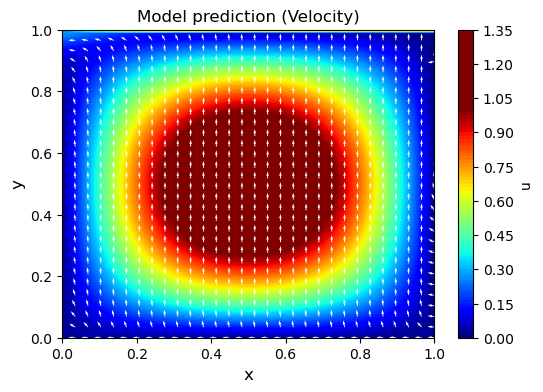

In [31]:
# define plot context
plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    function_names = ['u'],
    titles= ['Model prediction (Velocity)'],
    device=device,
    vmin=0,
    vmax=1,
    patches=[],
    N = 100
)

# 
def velocity(x: torch.Tensor) -> torch.Tensor:
    x.requires_grad_(True)
    out = model(x)
    u = out[:, 0:1]
    v = out[:, 1:2]
    
    return torch.cat([u, v], dim=1)

utils.plot_vector_field_2d([velocity], plot_ctx, N=100, n_width=30, n_heigth=30)

plot_ctx.vmin=-0.53
plot_ctx.vmax=-0.43
plot_ctx.titles = ['Model prediction (Streamfunction)']
plot_ctx.function_names = [r'$\psi$']

#utils.plot_function_on_2d_cube([lambda x: model(x)[:, 0]], plot_ctx)

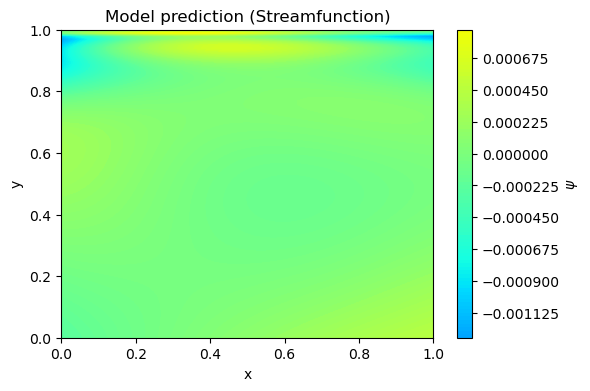

In [32]:
plot_ctx.vmax=0.003
plot_ctx.vmin=-0.003
utils.plot_function_on_2d_cube([lambda x: bnd_model(x)[:, 1]], plot_ctx)